# 03 — Multivariate Analysis: PCA, SVD & AFC

**Goal:** Apply dimensionality reduction to understand the latent structure
in student performance data.

**Techniques covered:**
| Method | Data type | What it reveals |
|---|---|---|
| **PCA** | Continuous grades (standardised) | Main axes of variation in grades |
| **SVD** | Raw grade matrix | Matrix factorisation view (equivalent to PCA) |
| **AFC** | Contingency tables (categorical) | Associations between categorical vars |
| **Biplots** | PCA output | Variables and students in the same space |



## 1. Imports



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
import warnings
warnings.filterwarnings("ignore")

CLEAN = Path("../data/clean")
FIG   = Path("../figures/multivariate")
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
PROMO_COLORS = {1: "#4C72B0", 2: "#55A868", 3: "#C44E52"}

panel    = pd.read_csv(CLEAN / "panel.csv")
notes    = pd.read_csv(CLEAN / "notes_clean.csv")
matieres = pd.read_csv(CLEAN / "matieres_clean.csv")

# Identify grade columns (subject-level scores)
grade_cols = [c for c in panel.columns
              if c not in ["id","promo","moy_s1","moy_s2","moy_ann","rang",
                            "passage","passage_bin","rang_norm","delta_s2_s1",
                            "top_quartile","bottom_quartile","is_outlier",
                            "genre","origine","bac","licence","promotion"]
              and not c.startswith("mod_")]

print(f"Grade columns for PCA: {grade_cols}")
print(f"Panel shape: {panel.shape}")


Grade columns for PCA: ['Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses', 'ent de données', "fond de l'IA", 'gest des ress hum', 'init au big data', 'mod UML/OCL', 'opt prog lineaire', 'opt&prog nn lin', 'prog java 2', 'prog log', 'sem et proj', 'tech sem', 'test log', 'théo de l inf cod cr', 'virtualisation', 'vtes ind']
Panel shape: (100, 52)


## 2. Build the Grade Matrix X

Rows = students, Columns = subjects.
We use all available subjects. Missing values imputed with column mean.



In [2]:
# Also include semester-level averages for richer PCA
feature_cols = (grade_cols if grade_cols else []) + ["moy_s1", "moy_s2"]
feature_cols = list(dict.fromkeys(feature_cols))  # deduplicate

X_raw = panel[["id", "promo"] + feature_cols].copy()
X_raw = X_raw.dropna(subset=feature_cols, how="all")

# Impute with column mean
for col in feature_cols:
    X_raw[col] = X_raw[col].fillna(X_raw[col].mean())

X       = X_raw[feature_cols].values
ids     = X_raw["id"].values
promos  = X_raw["promo"].values

print(f"Grade matrix X shape: {X.shape}")
print(f"Features: {feature_cols}")


Grade matrix X shape: (100, 28)
Features: ['Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses', 'ent de données', "fond de l'IA", 'gest des ress hum', 'init au big data', 'mod UML/OCL', 'opt prog lineaire', 'opt&prog nn lin', 'prog java 2', 'prog log', 'sem et proj', 'tech sem', 'test log', 'théo de l inf cod cr', 'virtualisation', 'vtes ind', 'moy_s1', 'moy_s2']


## 3. Standardise



In [3]:
scaler  = StandardScaler()
X_std   = scaler.fit_transform(X)

print("After standardisation:")
print(f"  Mean: {X_std.mean():.4f}  (should be ~0)")
print(f"  Std:  {X_std.std():.4f}   (should be ~1)")


After standardisation:
  Mean: -0.0000  (should be ~0)
  Std:  1.0000   (should be ~1)


## 4. PCA



In [4]:
n_components = min(len(feature_cols), len(X_std) - 1, 10)
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_std)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance per component:")
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {ev*100:.1f}%   cumulative: {cv*100:.1f}%")


Explained variance per component:
  PC1: 41.4%   cumulative: 41.4%
  PC2: 9.0%   cumulative: 50.5%
  PC3: 6.9%   cumulative: 57.4%
  PC4: 6.1%   cumulative: 63.5%
  PC5: 4.3%   cumulative: 67.7%
  PC6: 3.5%   cumulative: 71.3%
  PC7: 3.2%   cumulative: 74.5%
  PC8: 2.8%   cumulative: 77.3%
  PC9: 2.6%   cumulative: 79.8%
  PC10: 2.5%   cumulative: 82.3%


### 4a. Scree Plot



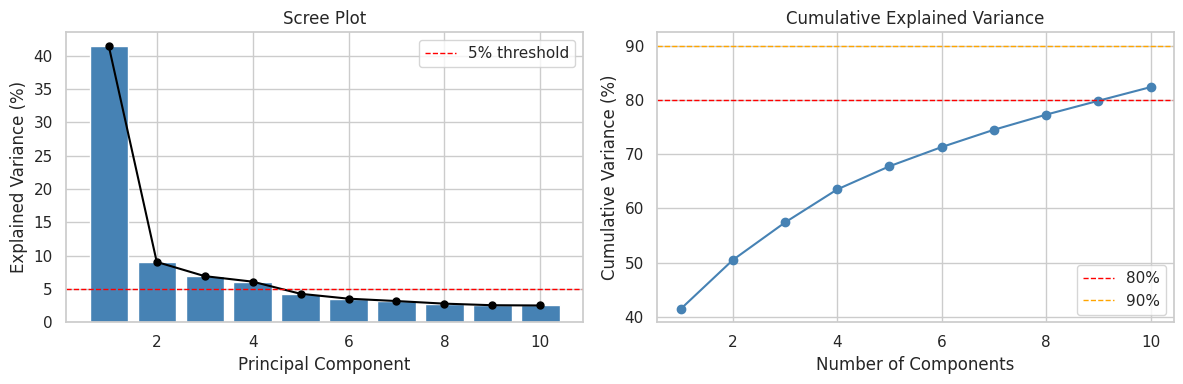


10 components explain >= 80% of variance.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(explained)+1), explained*100, color="steelblue", edgecolor="white")
ax1.plot(range(1, len(explained)+1), explained*100, "o-", color="black", ms=5)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_title("Scree Plot")
ax1.axhline(5, color="red", lw=1, linestyle="--", label="5% threshold")
ax1.legend()

ax2.plot(range(1, len(cumulative)+1), cumulative*100, "o-", color="steelblue")
ax2.axhline(80, color="red", lw=1, linestyle="--", label="80%")
ax2.axhline(90, color="orange", lw=1, linestyle="--", label="90%")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_title("Cumulative Explained Variance")
ax2.legend()

plt.tight_layout()
plt.savefig(FIG / "pca_scree.png", dpi=150)
plt.show()

n_keep = int(np.searchsorted(cumulative, 0.80)) + 1
print(f"\n{n_keep} components explain >= 80% of variance.")


In [6]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_[:n_keep],
    columns=feature_cols
)

print(loadings)


   Devp mob    TOEIC3    TOEIC4     agile  algo num2  algo.num1  appr auto  \
0  0.201742  0.154227  0.160926  0.163935   0.161301   0.196066   0.218334   
1 -0.007737  0.286084  0.388181  0.360214  -0.374360  -0.136193  -0.033048   
2 -0.036449 -0.022200 -0.094454 -0.184590  -0.001242  -0.165803  -0.229039   
3  0.102549 -0.103502 -0.204616  0.102361   0.094285  -0.085409   0.180658   
4  0.202769  0.286022  0.180050 -0.183000  -0.016588  -0.051299   0.045662   
5 -0.289616  0.472390  0.104294 -0.113234   0.057834  -0.011293  -0.165605   
6 -0.389963  0.172250  0.006225  0.144965   0.162932  -0.067337  -0.019611   
7  0.241798  0.089509  0.138795 -0.015842  -0.072857  -0.035633   0.132347   
8 -0.024911  0.023287 -0.051433  0.097279  -0.106107  -0.285554   0.221416   
9 -0.162815 -0.153318 -0.235775 -0.043661   0.025464   0.239074   0.011213   

   ches de mkv-fil d'at  cloud comp   devops1  ...  prog java 2  prog log  \
0              0.195026    0.213789  0.164698  ...     0.150500 

### 4b. Biplot — Students + Variables on PC1/PC2



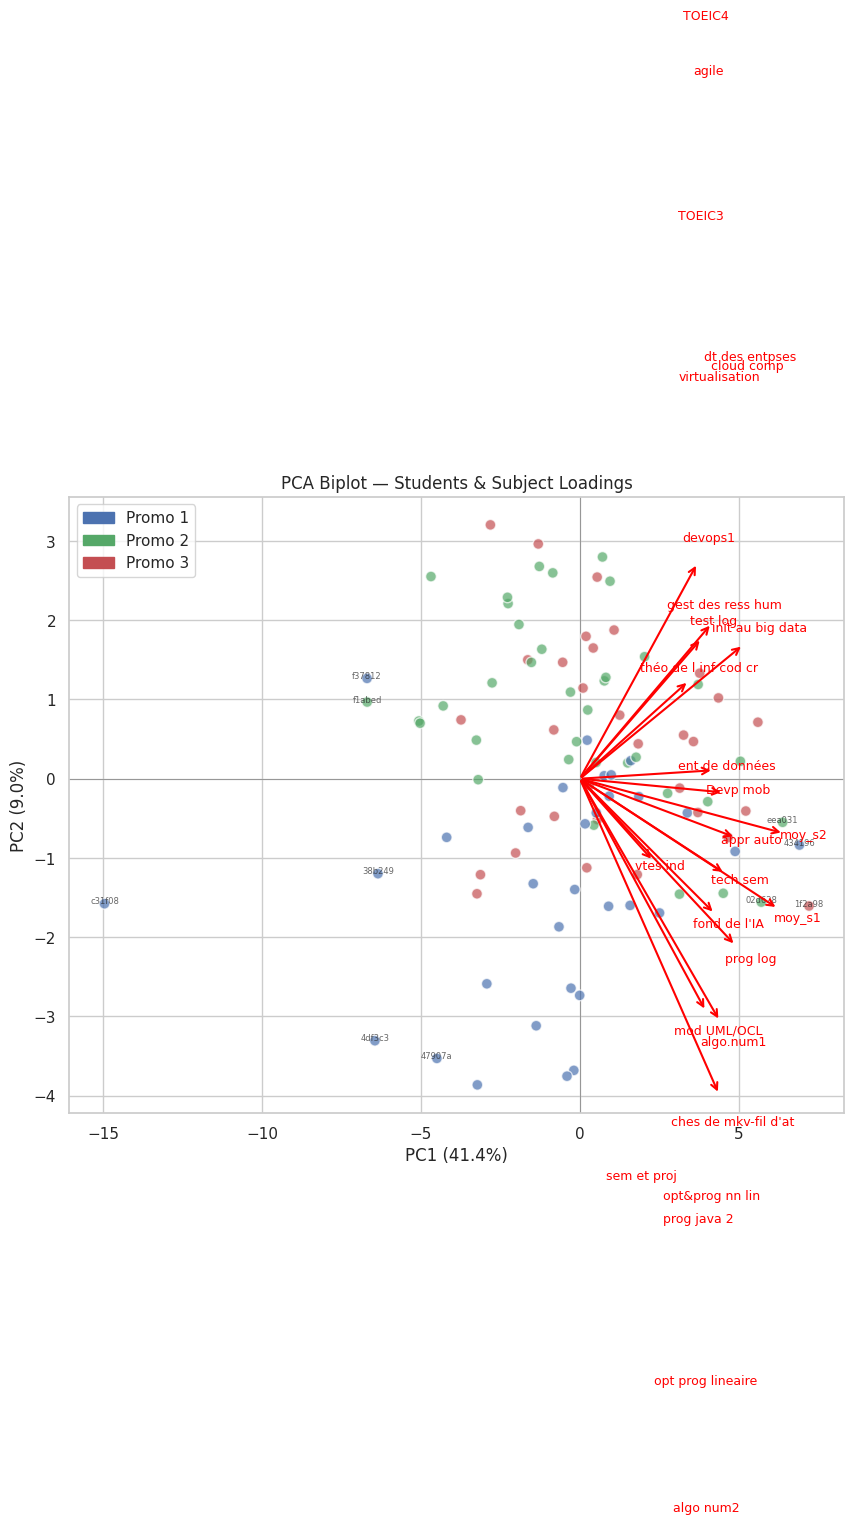

In [7]:
def biplot(scores, loadings, feature_names, labels, colors,
           title="Biplot PC1 / PC2", scale=1.5):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Student points
    scatter = ax.scatter(scores[:, 0], scores[:, 1],
                         c=[colors[p] for p in labels],
                         alpha=0.7, s=60, edgecolors="white", zorder=3)

    # Annotate 5% most extreme students
    extremes = np.argsort(np.linalg.norm(scores[:, :2], axis=1))[-max(5, len(scores)//10):]
    for i in extremes:
        ax.annotate(ids[i][:6], (scores[i, 0], scores[i, 1]),
                    fontsize=6, alpha=0.7, ha="center")

    # Loading arrows
    scale_factor = scale * max(np.abs(scores[:, :2]).max(), 1)
    for j, feat in enumerate(feature_names):
        u, v = loadings[0, j] * scale_factor, loadings[1, j] * scale_factor
        ax.annotate("", xy=(u, v), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
        ax.text(u * 1.1, v * 1.1, feat, color="red", fontsize=9, ha="center")

    # Legend
    patches = [mpatches.Patch(color=colors[p], label=f"Promo {p}") for p in sorted(colors)]
    ax.legend(handles=patches)
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
    ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
    ax.set_title(title)
    plt.tight_layout()
    return fig

fig = biplot(X_pca, pca.components_[:2], feature_cols, promos, PROMO_COLORS,
             title="PCA Biplot — Students & Subject Loadings")
plt.savefig(FIG / "pca_biplot.png", dpi=150)
plt.show()


### 4c. Loadings Heatmap — What Does Each PC Represent?



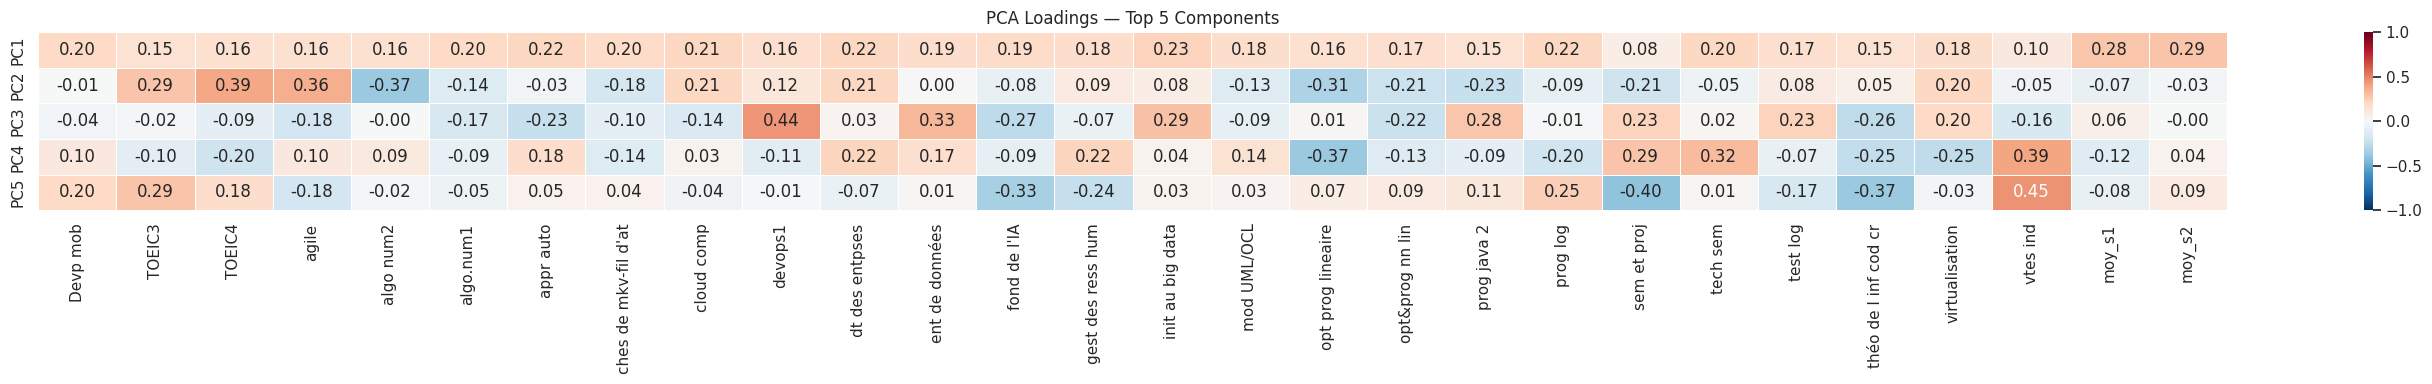


PC1 top loadings:
moy_s2              0.285529
moy_s1              0.277517
init au big data    0.228841
appr auto           0.218334
prog log            0.217923
Name: PC1, dtype: float64


In [8]:
loadings_df = pd.DataFrame(
    pca.components_[:min(5, n_components)],
    columns=feature_cols,
    index=[f"PC{i+1}" for i in range(min(5, n_components))]
)

fig, ax = plt.subplots(figsize=(max(6, len(feature_cols)), 4))
sns.heatmap(loadings_df, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("PCA Loadings — Top 5 Components")
plt.tight_layout()
plt.savefig(FIG / "pca_loadings.png", dpi=150)
plt.show()

print("\nPC1 top loadings:")
print(loadings_df.loc["PC1"].abs().sort_values(ascending=False).head())


### 4d. PC1/PC2 Scores by Promo (boxplot)



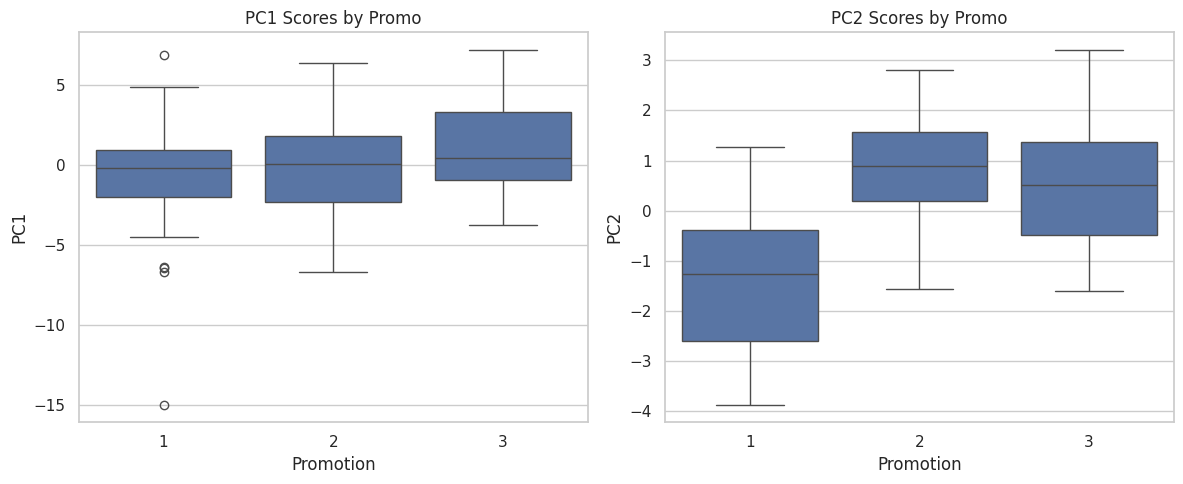

In [9]:
pc_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pc_df["promo"] = promos
pc_df["promo_str"] = (
    pc_df["promo"]
    .astype(str)
    .str.extract(r"(\d)")   # keep only 1,2,3
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    sns.boxplot(
    data=pc_df,
    x="promo_str",
    y=pc,              # IMPORTANT
    order=["1", "2", "3"],
    ax=ax
    )

    ax.set_title(f"{pc} Scores by Promo")
    ax.set_xlabel("Promotion")
plt.tight_layout()
plt.savefig(FIG / "pca_scores_by_promo.png", dpi=150)
plt.show()


## 5. SVD (Direct Matrix Factorisation)

SVD decomposes X_std = U Σ V^T.
- U: student coordinates in latent space
- V: subject coordinates (loadings)
- Σ: singular values (importance of each dimension)

Note: PCA on standardised data is equivalent to SVD on X_std.
Here we show SVD explicitly on the raw (non-standardised) grade matrix.



SVD singular values (top 8):
  dim 1: sigma=34.058  var=41.4%  cumul=41.4%
  dim 2: sigma=15.917  var=9.0%  cumul=50.5%
  dim 3: sigma=13.918  var=6.9%  cumul=57.4%
  dim 4: sigma=13.058  var=6.1%  cumul=63.5%
  dim 5: sigma=10.932  var=4.3%  cumul=67.7%
  dim 6: sigma=9.951  var=3.5%  cumul=71.3%
  dim 7: sigma=9.439  var=3.2%  cumul=74.5%
  dim 8: sigma=8.840  var=2.8%  cumul=77.3%


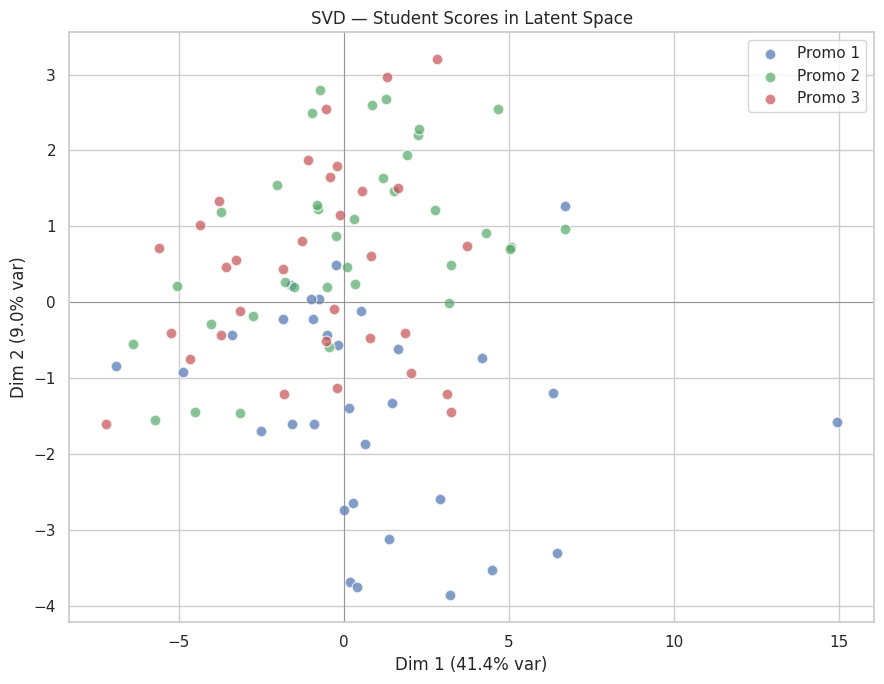

  k=1: reconstruction error = 0.7653
  k=2: reconstruction error = 0.7037
  k=3: reconstruction error = 0.6528
  k=4: reconstruction error = 0.6043
  k=5: reconstruction error = 0.5679
  k=6: reconstruction error = 0.5359
  k=7: reconstruction error = 0.5053
  k=8: reconstruction error = 0.4769
  k=9: reconstruction error = 0.4493
  k=10: reconstruction error = 0.4204


In [10]:
U, s, Vt = np.linalg.svd(X_std, full_matrices=False)
total_var = np.sum(s**2)
svd_var   = (s**2 / total_var * 100)

print("SVD singular values (top 8):")
for i, (sv, ev) in enumerate(zip(s[:8], svd_var[:8])):
    print(f"  dim {i+1}: sigma={sv:.3f}  var={ev:.1f}%  cumul={svd_var[:i+1].sum():.1f}%")

# SVD biplot (same as PCA, confirm they match)
fig, ax = plt.subplots(figsize=(9, 7))
U_scaled = U[:, :2] * s[:2]
for promo in [1, 2, 3]:
    mask = promos == promo
    ax.scatter(U_scaled[mask, 0], U_scaled[mask, 1],
               color=PROMO_COLORS[promo], alpha=0.7, label=f"Promo {promo}",
               edgecolors="white", s=60)
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel(f"Dim 1 ({svd_var[0]:.1f}% var)")
ax.set_ylabel(f"Dim 2 ({svd_var[1]:.1f}% var)")
ax.set_title("SVD — Student Scores in Latent Space")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "svd_scores.png", dpi=150)
plt.show()

# Reconstruction quality: how many dims to approximate X well?
reconstruction_errors = []
for k in range(1, min(len(s), 10) + 1):
    X_recon = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    err = np.linalg.norm(X_std - X_recon, "fro") / np.linalg.norm(X_std, "fro")
    reconstruction_errors.append(err)
    print(f"  k={k}: reconstruction error = {err:.4f}")


## 6. AFC — Analyse Factorielle des Correspondances

AFC applies to a **contingency table** of two categorical variables.
Classic example: passage (Admis/Rattrapage) × Promotion.
We implement AFC from scratch to show the maths.



In [11]:
def afc(contingency_table, n_components=2):
    """
    Analyse Factorielle des Correspondances from scratch.
    Returns row/col coordinates and explained inertia.
    """
    N  = contingency_table.values.astype(float)
    n  = N.sum()
    P  = N / n                        # correspondence matrix
    r  = P.sum(axis=1)                # row marginals
    c  = P.sum(axis=0)                # col marginals
    Dr = np.diag(1 / np.sqrt(r))
    Dc = np.diag(1 / np.sqrt(c))
    S  = Dr @ (P - np.outer(r, c)) @ Dc   # standardised residuals matrix
    U, s, Vt = np.linalg.svd(S, full_matrices=False)
    total_inertia = np.sum(s**2)
    inertia_pct = s**2 / total_inertia * 100

    row_coords = Dr @ U[:, :n_components] * s[:n_components]
    col_coords = Dc @ Vt.T[:, :n_components] * s[:n_components]

    return row_coords, col_coords, inertia_pct, total_inertia


### 6a. AFC: Passage × Promo



Contingency table Promo × Passage:
passage  Admis  Rattrapage
promo                     
1           27           5
2           27           9
3           30           2

Chi2 expected (proportional):
[[26.88  5.12]
 [30.24  5.76]
 [26.88  5.12]]

Total inertia: 0.0444
Dim 1: 100.0%   Dim 2: 0.0%


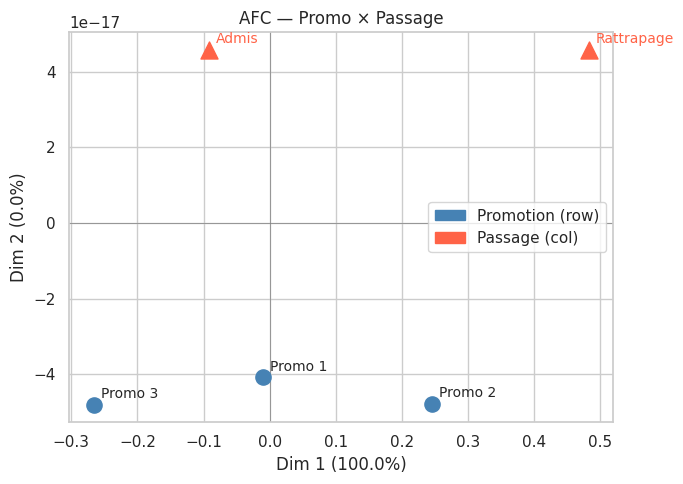

In [12]:
ct_passage = pd.crosstab(panel["promo"], panel["passage"])
print("Contingency table Promo × Passage:")
print(ct_passage)
print(f"\nChi2 expected (proportional):\n{ct_passage.sum(axis=1).values[:, None] @ ct_passage.sum(axis=0).values[None, :] / len(panel)}")

row_c, col_c, inertia, total_i = afc(ct_passage)
print(f"\nTotal inertia: {total_i:.4f}")
print(f"Dim 1: {inertia[0]:.1f}%   Dim 2: {inertia[1]:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
for i, label in enumerate(ct_passage.index):
    ax.scatter(row_c[i, 0], row_c[i, 1], color="steelblue", s=120, zorder=4)
    ax.annotate(f"Promo {label}", (row_c[i, 0], row_c[i, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=10)
for j, label in enumerate(ct_passage.columns):
    ax.scatter(col_c[j, 0], col_c[j, 1], color="tomato", marker="^", s=150, zorder=4)
    ax.annotate(label, (col_c[j, 0], col_c[j, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=10, color="tomato")
ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5)
ax.set_xlabel(f"Dim 1 ({inertia[0]:.1f}%)")
ax.set_ylabel(f"Dim 2 ({inertia[1]:.1f}%)")
ax.set_title("AFC — Promo × Passage")
blue_patch  = mpatches.Patch(color="steelblue", label="Promotion (row)")
red_patch   = mpatches.Patch(color="tomato",    label="Passage (col)")
ax.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.savefig(FIG / "afc_passage_promo.png", dpi=150)
plt.show()


### 6b. AFC: Bac type × Performance quartile (if demographic data available)



In [17]:
if "bac" in panel.columns:
    panel["quartile_label"] = pd.qcut(panel["moy_ann"], q=3,
                                       labels=["Q1-Faible","Q2","Q3","Q4-Fort"])
    ct_bac = pd.crosstab(panel["bac"], panel["quartile_label"])
    print("\nContingency table Bac × Quartile:")
    print(ct_bac)

    if ct_bac.shape[0] >= 2 and ct_bac.shape[1] >= 2:
        row_c2, col_c2, inertia2, _ = afc(ct_bac)

        fig, ax = plt.subplots(figsize=(8, 6))
        for i, label in enumerate(ct_bac.index):
            ax.scatter(row_c2[i, 0], row_c2[i, 1], color="steelblue", s=120, zorder=4)
            ax.annotate(str(label), (row_c2[i, 0], row_c2[i, 1]),
                        textcoords="offset points", xytext=(5, 5), fontsize=9)
        for j, label in enumerate(ct_bac.columns):
            ax.scatter(col_c2[j, 0], col_c2[j, 1], color="tomato", marker="^", s=150, zorder=4)
            ax.annotate(str(label), (col_c2[j, 0], col_c2[j, 1]),
                        textcoords="offset points", xytext=(5, 5), fontsize=9, color="tomato")
        ax.axhline(0, color="grey", lw=0.5)
        ax.axvline(0, color="grey", lw=0.5)
        ax.set_xlabel(f"Dim 1 ({inertia2[0]:.1f}%)")
        ax.set_ylabel(f"Dim 2 ({inertia2[1]:.1f}%)")
        ax.set_title("AFC — Type de Bac × Quartile de Performance")
        plt.tight_layout()
        plt.savefig(FIG / "afc_bac_quartile.png", dpi=150)
        plt.show()
else:
    print("Demographic column 'bac' not found in panel — skipping AFC Bac × Quartile.")
    print("(Run after profils is joined correctly in notebook 01.)")


ValueError: Bin labels must be one fewer than the number of bin edges

## 7. PCA on Subject-Level Data (Long Format)

Instead of one PCA per student, do a PCA where rows = (student × semestre)
and we look at module-level structure.



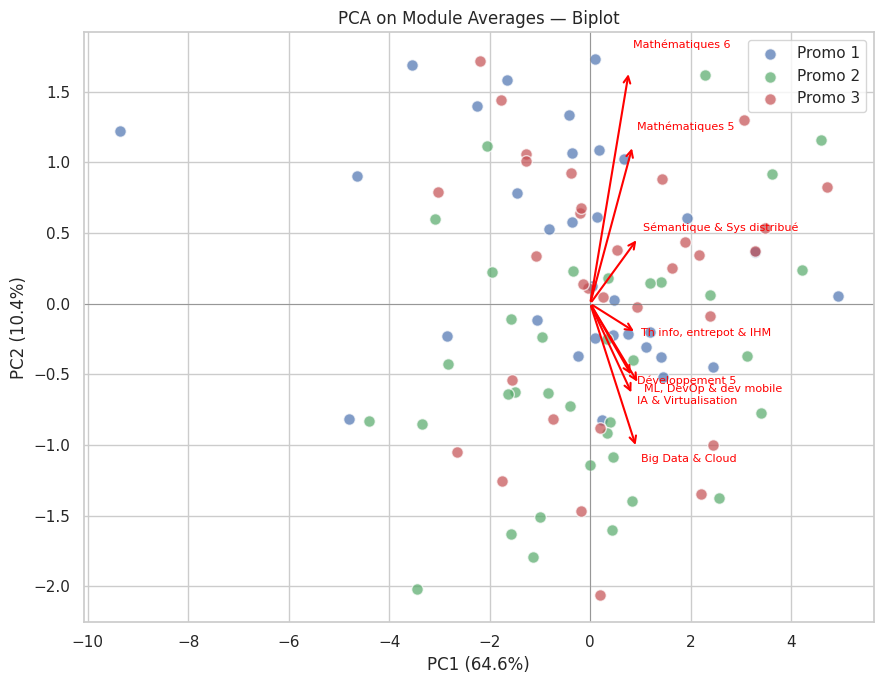

In [14]:
if len(mod_cols := [c for c in panel.columns if c.startswith("mod_")]) >= 2:
    Xm = panel[mod_cols].dropna()
    ids_m = panel.loc[Xm.index, "id"].values
    promos_m = panel.loc[Xm.index, "promo"].values

    Xm_std = StandardScaler().fit_transform(Xm)
    pca_m = PCA(n_components=min(len(mod_cols), 4))
    Xm_pca = pca_m.fit_transform(Xm_std)

    fig, ax = plt.subplots(figsize=(9, 7))
    for promo in [1, 2, 3]:
        mask = promos_m == promo
        ax.scatter(Xm_pca[mask, 0], Xm_pca[mask, 1],
                   color=PROMO_COLORS[promo], alpha=0.7, label=f"Promo {promo}",
                   edgecolors="white", s=70)

    # Module loadings
    scale = 2.5
    for j, feat in enumerate(mod_cols):
        u = pca_m.components_[0, j] * scale
        v = pca_m.components_[1, j] * scale
        ax.annotate("", xy=(u, v), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
        ax.text(u*1.1, v*1.1, feat.replace("mod_", ""), color="red", fontsize=8)

    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)
    ax.set_xlabel(f"PC1 ({pca_m.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca_m.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title("PCA on Module Averages — Biplot")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG / "pca_modules_biplot.png", dpi=150)
    plt.show()


## 8. Summary



In [15]:
print("=== Multivariate Analysis Summary ===")
print(f"PCA: {n_keep} components explain >= 80% variance")
print(f"  PC1 captures: {explained[0]*100:.1f}%  PC2: {explained[1]*100:.1f}%")
print(f"SVD matches PCA (standardised data): confirmed above")
print(f"AFC Promo x Passage: total inertia = {total_i:.4f}")
print("\nKey takeaways:")
print("  - Look at PC1 loadings to identify the 'main performance axis'")
print("  - AFC reveals which promos are most associated with each passage outcome")
print("  - Use PCA scores as input to clustering (notebook 04)")


=== Multivariate Analysis Summary ===
PCA: 10 components explain >= 80% variance
  PC1 captures: 41.4%  PC2: 9.0%
SVD matches PCA (standardised data): confirmed above
AFC Promo x Passage: total inertia = 0.0444

Key takeaways:
  - Look at PC1 loadings to identify the 'main performance axis'
  - AFC reveals which promos are most associated with each passage outcome
  - Use PCA scores as input to clustering (notebook 04)
